In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skewnorm

In [8]:
rng = np.random.default_rng()

In [9]:
def dist(L, x1, y1, x2, y2):
    
    dx = x2 - x1
    dx -= L*round(dx/L)
    dy = y2 - y1
    dy -= L*round(dy/L)
    
    return dx, dy

In [10]:
def force_x(L, k_0, r_0, x1, y1, x2, y2):
    '''This function evaluates the horizontal force acting 
    on the particle at a position (x1, y1) due to another
    particle located at (x2, y2)'''
    dx, dy = dist(L, x1, y1, x2, y2)
    r = np.sqrt(dx*dx + dy*dy)
    if r > r_0 or r == 0:
        f_x = 0
    else:
        f_x = -k_0*(r_0 - r)*(dx)/r

    return f_x
     

In [11]:
def force_y(L, k_0, r_0, x1, y1, x2, y2):
    '''This function evaluates the vertical force acting 
    on the particle at a position (x1, y1) due to another
    particle located at (x2, y2)'''
    dx, dy = dist(L, x1, y1, x2, y2)
    r = np.sqrt(dx*dx + dy*dy)
    if r > r_0 or r == 0:
        f_y = 0
    else:
        f_y = -k_0*(r_0 - r)*(dy)/r

    return f_y

In [29]:
def particle_trajectory_m(P, k_0, r_0, k, w, D_r, L, delta_t, N, x_0, y_0, theta_0):
    
    x_grid = np.zeros((N, P))
    y_grid = np.zeros((N, P))
    theta_grid = np.zeros((N, P))
    for i in range(P):
        x_grid[0][i] = x_0[i]
        y_grid[0][i] = y_0[i]
        theta_grid[0][i] = theta_0[i]
    i = 1

    while i < N:
        for j in range(P):
            force_h = 0
            force_v = 0
            for l in range(P):
                force_h += force_x(L, k_0, r_0, x_grid[i-1][j], y_grid[i-1][j], x_grid[i-1][l], y_grid[i-1][l])
                force_v += force_y(L, k_0, r_0, x_grid[i-1][j], y_grid[i-1][j], x_grid[i-1][l], y_grid[i-1][l])
            x_grid[i][j] = x_grid[i-1][j] + np.cos(theta_grid[i-1][j])*delta_t + force_h*delta_t
            y_grid[i][j] = y_grid[i-1][j] + np.sin(theta_grid[i-1][j])*delta_t + force_v*delta_t

            d_beta = rng.normal(0, np.sqrt(delta_t))
            theta_grid[i][j] = (theta_grid[i-1][j] + (1 + w)*delta_t + force_h*np.cos(theta_grid[i-1][j])*delta_t +
                                                force_v*np.sin(theta_grid[i-1][j])*delta_t + np.sqrt(2*D_r)*d_beta)
            if x_grid[i][j] > L:
                x_grid[i][j] = 0 + (x_grid[i][j] - L*np.floor(x_grid[i][j]/L))
            elif x_grid[i][j] < 0:
                x_grid[i][j] = L + (x_grid[i][j] - L*(np.floor(x_grid[i][j]/L)+1))
            if y_grid[i][j] > L:
                y_grid[i][j] = 0 + (y_grid[i][j] - L*np.floor(y_grid[i][j]/L))
            elif y_grid[i][j] < 0:
                y_grid[i][j] = L + (y_grid[i][j] - L*(np.floor(y_grid[i][j]/L)+1))
        i += 1

    return x_grid, y_grid, theta_grid

In [30]:
print(np.floor(-0.8))

-1.0


In [41]:
x_in = np.zeros(500)
y_in = np.zeros(500)
t_in = np.zeros(500)

for i in range(500):
    x_in[i] = 1.0
    y_in[i] = 0
    t_in[i] = 0
    
    

In [137]:
x500, y500, t500 = particle_trajectory_m(500, 15, 7.0, 15, -0.65, 0.05, 40.0, 0.01, 1000, x_in, y_in, t_in)
y1 = y[:, 0]
y2 = y[:, 1]

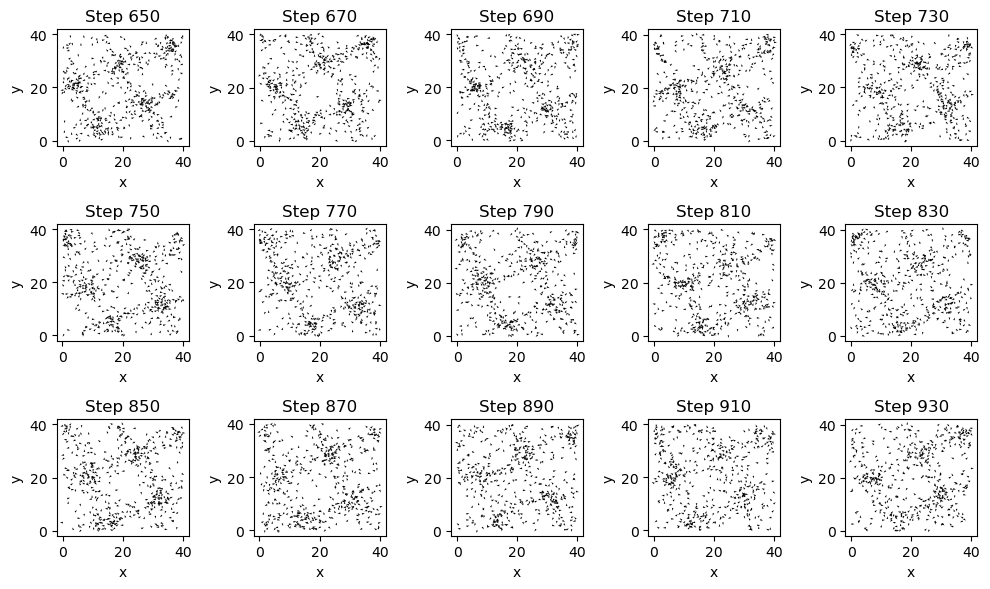

In [217]:
fig_2D = plt.figure(figsize=(10,6),tight_layout=True)
index = 1
for i in range(15):
    ax = fig_2D.add_subplot(3, 5, index)
    #ax.plot(x[200 + 2*i], y[200 + 2*i], '.')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(f'Step {650 + 20*i}')
    xi = x500[650 + 20*i]
    yi = y500[650 + 20*i]
    dx = np.cos(t500[650 + 20*i])
    dy = np.sin(t500[650 + 20*i])

    # Add arrows
    # create colour array
    P = len(xi)
    colors = ['red']*0 + ['black']*(P-1)

    # Add arrows with different colours
    ax.quiver(xi, yi, dx, dy,
              angles='xy',
              scale_units='xy',
              scale=1,
              width=0.02,
              color=colors)

    index += 1

plt.savefig('Chiral_MIPS')